In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_score
from scipy.stats import uniform
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df_raw = pd.read_csv(r'C:\Users\raibe\Desktop\full-flow\preprocessed data\feature_engineered_anime_alt.csv').copy()
df_raw

,title,score,people_scored,popularity,members,season,studio,description,recommended,mixed_feelings,not_recommended,rec,mix,not_rec,show_type,status,aired,source,genres,duration_min,episodes,rating,favorites,reviews,favs_rate,desc_length,scored_rate,rec_share,mix_share,not_rec_share,sentiment_balance
0,sousou no frieren,9.27,869731,104,1411377,fall 2023,madhouse,during their decade-long quest to defeat the d...,819,144,116,i feel so catered to.\r\n\r\nit feels like an ...,someone recommended me to watch this title las...,style-\r\nfrieren doesn't have its own unique ...,tv,finished airing,"sep 29, 2023 to mar 22, 2024",manga,"adventure, award winning, drama, fantasy",24.0,28.0,pg-13 - teens 13 or older,88070,1079,6.240005e-02,1099,0.616229,0.759036,0.133457,0.107507,0.651529
1,steel ball run: jojo no kimyou na bouken,9.16,86411,1447,189929,spring 2026,david production,"in the american old west, the world's greatest...",156,7,1,i watched the first episode and it was truly a...,i will summarize it for you in two words.\r\nn...,the part 7 adaption is similar to its previous...,ona,currently airing,"mar 19, 2026 to ?",manga,"action, adventure, mystery, supernatural",47.0,11.0,r - 17+ (violence & profanity),6051,164,3.185927e-02,1194,0.454965,0.951220,0.042683,0.006098,0.945122
2,fullmetal alchemist: brotherhood,9.11,2303444,3,3667785,spring 2009,bones,after a horrific alchemy experiment goes wrong...,971,69,44,"first of all, i have seen the original fma and...",fullmetal alchemist: brotherhood gets an immen...,*spoiler warning\r\n\r\naside from the usual e...,tv,finished airing,"apr 5, 2009 to jul 4, 2010",manga,"action, adventure, drama, fantasy",24.0,64.0,r - 17+ (violence & profanity),241796,1084,6.592426e-02,1169,0.628020,0.895756,0.063653,0.040590,0.855166
3,chainsaw man movie: reze-hen,9.09,282353,589,449212,fall 2025,mappa,despite the immediate challenges following bec...,322,46,19,in short if you like and read the chainsaw man...,quick little review because i feel my perspect...,writing this review to compile my thoughts on ...,movie,finished airing,"sep 19, 2025",manga,"action, fantasy",99.0,1.0,r - 17+ (violence & profanity),12951,387,2.883049e-02,865,0.628552,0.832041,0.118863,0.049096,0.782946
4,steins;gate,9.07,1516022,14,2802086,spring 2011,white fox,eccentric scientist rintarou okabe has a never...,1075,88,84,“no one knows what the future holds. that’s wh...,one word: hype.\r\n\r\nbefore watching this sh...,just a horrible anime. this is the anime equiv...,tv,finished airing,"apr 6, 2011 to sep 14, 2011",visual novel,"drama, sci-fi, suspense",24.0,24.0,pg-13 - teens 13 or older,201780,1247,7.201064e-02,1144,0.541033,0.862069,0.070569,0.067362,0.794707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10137,neko neko nihonshi 2nd season,6.13,285,15277,991,spring 2017,joker films,second season of neko neko nihonshi.,0,0,0,unknown,unknown,unknown,tv,finished airing,"apr 5, 2017 to feb 28, 2018",web manga,comedy,9.0,32.0,g - all ages,1,0,1.009083e-03,36,0.287588,0.000000,0.000000,0.000000,0.000000
10138,ninkuu (movie),6.13,848,12374,2198,summer 1995,studio pierrot,how much humiliation can four people and a pen...,1,1,0,this movie/ova/filler episode extracted out of...,rate a 5\r\nenglish dubbed\r\n\r\nstory\r\nif ...,unknown,movie,finished airing,"jul 15, 1995",manga,"action, adventure, comedy",26.0,1.0,g - all ages,3,2,1.364878e-03,757,0.385805,0.500000,0.500000,0.000000,0.500000
10139,number24 recap,6.13,950,11317,2959,spring 2020,pra,recap of the first ten episodes of number24 se...,0,0,0,unknown,unknown,unknown,tv special,finished airing,"apr 1, 2020",original,sports,23.0,1.0,pg-13 - teens 13 or older,2,0,6.759044e-04,51,0.321054,0.000000,0.000000,0.000000,0.000000
10140,onikiri musume saisen,6.13,448,15354,973,summer 2014,unknown,a girl and demon battle out on a field as they...,0,1,0,i don't know why i love to see sort stories wi...,unkno

In [4]:
df_rec = df_raw['rec'].loc[:5000]
df_mix = df_raw['mix'].loc[:5000]
df_not_rec = df_raw['not_rec'].loc[:5000]

In [5]:
df_rec     = pd.DataFrame({'text': df_raw['rec'].loc[:5000],     'target': 'rec'})
df_mix     = pd.DataFrame({'text': df_raw['mix'].loc[:5000],     'target': 'mix'})
df_not_rec = pd.DataFrame({'text': df_raw['not_rec'].loc[:5000], 'target': 'not_rec'})

df = pd.concat([df_rec, df_mix, df_not_rec], ignore_index=True)
df['text'] = df['text'].str.lower().str.strip()


df = df[df['text'] != 'unknown'].reset_index(drop=True)
print(f"Dataset size after removing 'unknown': {len(df)}")
print(df['target'].value_counts())

Dataset size after removing 'unknown': 12644
target
rec        4620
mix        4182
not_rec    3842
Name: count, dtype: int64


In [6]:
X = df[['text']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Random Forest Classifier with RandomizedSearchCV

In [7]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english'), 'text'),
        ]
    )),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [8]:
rf_param_distributions = {
    'clf__n_estimators':          randint(100, 500),
    'clf__max_depth':             [None, 10, 20, 30],
    'clf__min_samples_split':     randint(2, 20),
    'clf__min_samples_leaf':      randint(1, 10),
    'clf__max_features':          ['sqrt', 'log2'],
    'preprocessor__tfidf__ngram_range':   [(1, 1), (1, 2)],
    'preprocessor__tfidf__sublinear_tf':  [True, False],
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)
print(f"Best params: {rf_random_search.best_params_}")
print(f"Best CV F1 (weighted): {rf_random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 9, 'clf__min_samples_split': 8, 'clf__n_estimators': 108, 'preprocessor__tfidf__ngram_range': (1, 2), 'preprocessor__tfidf__sublinear_tf': True}
Best CV F1 (weighted): 0.5078


              precision    recall  f1-score   support

         mix       0.41      0.21      0.28       837
     not_rec       0.60      0.55      0.58       768
         rec       0.53      0.81      0.64       924

    accuracy                           0.53      2529
   macro avg       0.51      0.52      0.50      2529
weighted avg       0.51      0.53      0.50      2529

F1       (weighted): 0.5000
Recall   (weighted): 0.5306
Precision(weighted): 0.5128


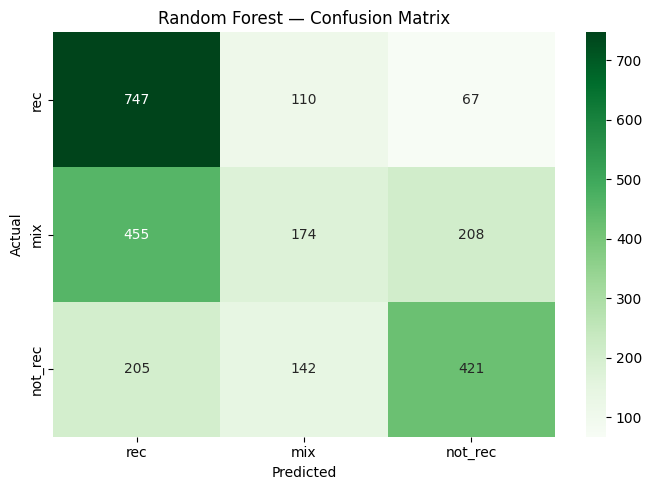

In [9]:
rf_best = rf_random_search.best_estimator_
rf_y_pred = rf_best.predict(X_test)

print(classification_report(y_test, rf_y_pred))

print(f"F1       (weighted): {f1_score(y_test, rf_y_pred, average='weighted'):.4f}")
print(f"Recall   (weighted): {recall_score(y_test, rf_y_pred, average='weighted'):.4f}")
print(f"Precision(weighted): {precision_score(y_test, rf_y_pred, average='weighted'):.4f}")

labels = ['rec', 'mix', 'not_rec']
rf_cm = confusion_matrix(y_test, rf_y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [10]:
a = pd.read_csv(r'C:\Users\raibe\Desktop\full-flow\origin data\anime.csv')
a.head()

,title,score,people_scored,popularity,members,season,title_type,studio,description,recommended,mixed_feelings,not_recommended,rec,mix,not_rec,english_title,show_type,status,aired,broadcast,producers,licensors,source,genres,duration,episodes,rating,themes,demographics,favorites
0,Sousou no Frieren,9.27,869731,Popularity #104,"Members 1,411,377",Fall 2023,TV,Madhouse,During their decade-long quest to defeat the D...,819,144,116,I feel so catered to.\r\n\r\nIt feels like an ...,Someone recommended me to watch this title las...,Style-\r\nFrieren doesn't have its own unique ...,Frieren: Beyond Journey's End,TV,Finished Airing,"Sep 29, 2023 to Mar 22, 2024",Fridays at 23:00 (JST),"Aniplex, Dentsu, Shogakukan-Shueis...",Crunchyroll,Manga,"AdventureAdventure, Award WinningAward...",24 min. per ep.,28,PG-13 - Teens 13 or older,NaN,ShounenShounen,"88,070"
1,Steel Ball Run: JoJo no Kimyou na Bouken,9.16,86411,Popularity #1447,"Members 189,929",NaN,ONA,David Production,"In the American Old West, the world's greatest...",156,7,1,I watched the first episode and it was truly a...,I will summarize it for you in two words.\r\nN...,The part 7 adaption is similar to its previous...,Steel Ball Run: JoJo's Bizarre Adventure,ONA,Currently Airing,"Mar 19, 2026 to ?",NaN,"Warner Bros. Japan, Studio Mausu, ...","None found, add some",Manga,"ActionAction, AdventureAdventure, ...",47 min.,Unknown,R - 17+ (violence & profanity),"HistoricalHistorical, RacingRacing","SeinenSeinen, ShounenShounen","6,051"
2,Fullmetal Alchemist: Brotherhood,9.11,2303444,Popularity #3,"Members 3,667,785",Spring 2009,TV,Bones,After a horrific alchemy experiment goes wrong...,971,69,44,"First of all, I have seen the original FMA and...",Fullmetal Alchemist: Brotherhood gets an immen...,*Spoiler Warning\r\n\r\nAside from the usual e...,Fullmetal Alchemist: Brotherhood,TV,Finished Airing,"Apr 5, 2009 to Jul 4, 2010",Sundays at 17:00 (JST),"Aniplex, Square Enix, Mainichi Bro...","Funimation, Aniplex of America",Manga,"ActionAction, AdventureAdventure, ...",24 min. per ep.,64,R - 17+ (violence & profanity),MilitaryMilitary,ShounenShounen,"241,796"
3,Chainsaw Man Movie: Reze-hen,9.09,282353,Popularity #589,"Members 449,212",NaN,Movie,MAPPA,Despite the immediate challenges following bec...,322,46,19,In short if you like and read the chainsaw man...,Quick little review because I feel my perspect...,Writing this review to compile my thoughts on ...,Chainsaw Man – The Movie: Reze Arc,Movie,Finished Airing,"Sep 19, 2025",NaN,"None found, add some","None found, add some",Manga,"ActionAction, FantasyFantasy",1 hr. 39 min.,1,R - 17+ (violence & profanity),"GoreGore, Urban FantasyUrban Fantasy",ShounenShounen,"12,951"
4,Steins;Gate,9.07,1516022,Popularity #14,"Members 2,802,086",Spring 2011,TV,White Fox,Eccentric scientist Rintarou Okabe has a never...,1075,88,84,“No one knows what the future holds. That’s wh...,One word: Hype.\r\n\r\nBefore watching this sh...,Just a horrible anime. This is the anime equiv...,Steins;Gate,TV,Finished Airing,"Apr 6, 2011 to Sep 14, 2011",Wednesdays at 02:05 (JST),"Frontier Works, Media Factory, Kad...",Funimation,Visual novel,"DramaDrama, Sci-FiSci-Fi, Susp...",24 min. per ep.,24,PG-13 - Teens 13 or older,"PsychologicalPsychological, Time Trave...",NaN,"201,780"


## Fully connected neural network

In [11]:
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim

In [12]:
X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_, y_, test_size=0.5, random_state=42, stratify=y_)

In [13]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    sublinear_tf=True,
    ngram_range=(1, 2),
)

X_train_transformed = tfidf.fit_transform(X_train['text'])
X_val_encoded       = tfidf.transform(X_val['text'])
X_test_encoded      = tfidf.transform(X_test['text'])
print(f"TF-IDF shape: {X_train_transformed.shape}")

TF-IDF shape: (10115, 10000)


In [14]:
LABEL2ID = {'rec': 0, 'mix': 1, 'not_rec': 2}

class AnimeReviewDataset(data.Dataset):
    def __init__(self, X, y):
        self.texts = torch.tensor(X.toarray(), dtype=torch.float32)
        self.labels = torch.tensor(y.map(LABEL2ID).tolist(), dtype=torch.long)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

In [15]:
train_data = AnimeReviewDataset(X_train_transformed, y_train)
train_data = data.DataLoader(train_data, batch_size=32, shuffle=True)

In [16]:
val_data = AnimeReviewDataset(X_val_encoded, y_val)
val_loader = data.DataLoader(val_data, batch_size=32, shuffle=False)

test_data = AnimeReviewDataset(X_test_encoded, y_test)
test_loader = data.DataLoader(test_data, batch_size=32, shuffle=False)

In [17]:
class ReviewNN(nn.Module):
    def __init__(self, input_dim=10000, hidden1=512, hidden2=256, output_dim=3, dropout=0.4):
        super(ReviewNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [19]:
model = ReviewNN().to(device)

In [20]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1, 2])
class_weights = compute_class_weight('balanced', classes=classes, y=y_train.map(LABEL2ID).values)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class weights: {class_weights}")

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

EPOCHS = 50
PATIENCE = 1

Class weights: [0.91224747 1.0079721  1.09683366]


In [21]:
best_val_loss = float('inf')
patience_counter = 1
best_model_state = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for texts, labels in train_data:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for texts, labels in val_loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            val_loss += criterion(outputs, labels).item()

    train_loss /= len(train_data)
    val_loss   /= len(val_loader)
    scheduler.step(val_loss)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_model_state)
print("Loaded best model weights.")

Epoch 01 | Train Loss: 0.9964 | Val Loss: 0.9411 | LR: 1.00e-03
Epoch 02 | Train Loss: 0.7231 | Val Loss: 1.0539 | LR: 1.00e-03
Early stopping at epoch 2
Loaded best model weights.


              precision    recall  f1-score   support

         mix       0.46      0.26      0.33       419
     not_rec       0.61      0.70      0.65       384
         rec       0.59      0.75      0.66       462

    accuracy                           0.57      1265
   macro avg       0.55      0.57      0.55      1265
weighted avg       0.55      0.57      0.55      1265



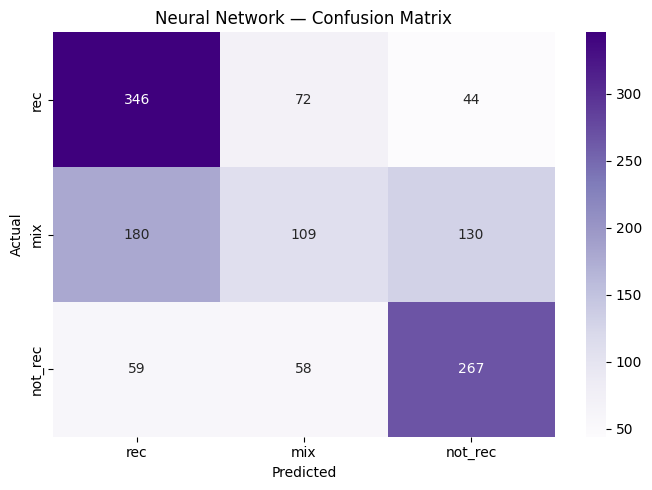

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        outputs = model(texts)
        preds = outputs.argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

ID2LABEL = {v: k for k, v in LABEL2ID.items()}
all_preds_str  = [ID2LABEL[p] for p in all_preds]
all_labels_str = [ID2LABEL[l] for l in all_labels]

print(classification_report(all_labels_str, all_preds_str))

labels_order = ['rec', 'mix', 'not_rec']
cm = confusion_matrix(all_labels_str, all_preds_str, labels=labels_order)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Neural Network — Confusion Matrix')
plt.tight_layout()
plt.show()